# Denoising AutoEncoder Anomaly Detector
Loss func: MSE

Denoising: Adds noise to the input data before training. Reconstruction loss uses unaltered input.

In [28]:
# Download the dataset, setup packages
import os
import cv2
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score

import torch as torch
import torch.nn as nn
import torch.optim as optim

if not os.path.exists('dataset.zip'):
  !gdown 1_pRKXtYRjWjY0seYqyx25nOxjtr-mHYg
  !unzip -q -u dataset.zip
else:
  print('Already downloaded')

Already downloaded


In [29]:
# Some helper functions
def load_dataset(class_name = 'pasta'):
  assert class_name in ['pasta', 'screws']
  dir = './dataset/'+class_name+'/'
  training_images = []
  testing_images = []
  testing_labels = []
  for file_name in os.listdir(dir+'train/good/'):
    training_images.append(cv2.cvtColor(cv2.imread(dir+'train/good/'+file_name), cv2.COLOR_BGR2RGB))
  for file_name in os.listdir(dir+'test/good/'):
    testing_images.append(cv2.cvtColor(cv2.imread(dir+'test/good/'+file_name), cv2.COLOR_BGR2RGB))
    testing_labels.append(0)
  for file_name in os.listdir(dir+'test/bad/'):
    testing_images.append(cv2.cvtColor(cv2.imread(dir+'test/bad/'+file_name), cv2.COLOR_BGR2RGB))
    testing_labels.append(1)

  # returns a normalized (0-1) numpy array of size (n,)
  return np.array(training_images)/255., np.array(testing_images)/255., np.array(testing_labels)

def basic_evaluation(predictions : np.ndarray, targets : np.ndarray):
  print(targets)
  print(predictions)
  print('AUROC Score:', roc_auc_score(targets, predictions))

In [30]:
# What size to make latent vector dim?
class Encoder(nn.Module):
    def __init__(self, image_height, image_width, latent_vector_dim = 128):
        super().__init__()

        '''
        Encoder has 3 3x3 convolutional layers which reduces dimensions in half each layer (stride = 2). These layers act as feature extractors

        Recall: stride is how many pixels filter slides (produces less outputs for bigger stride). It is 'learned downsampling'.
                In contrast pooling throws away backgroud noise and has no 'learning'
        '''

        self.convolution = nn.Sequential(
            # (in_channels, out_channels, kernel_size, stride, padding)
            nn.Conv2d(3,16,3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(16,32,3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64,3,stride=2,padding=1),
            nn.ReLU()
        )

        '''
        To get these values from latent vector, we use fully connected layer to scale down to 1 param (1 meam and 1 variance) (as mean and variance use all values in vector?)
        Options are nn.Linear(input_dim, output_dim) or nn.LazyLinear(output_dim) which does it for you?

        Using linear as we need these values anyways for our decoder. therefore we have to do a dummy pass to see the output shapes
        '''
        dummy_input = torch.zeros(1, 3, image_height, image_width)
        dummy_output = self.convolution(dummy_input)

        # Save this shape for the decoder to use later
        self.flattened_size = dummy_output.view(1, -1).size(1)
        self.spatial_shape = dummy_output.shape[1:]

        self.fc = nn.Linear(self.flattened_size, latent_vector_dim)

        # # fully connected layer
        # self.fully_connected_mu = nn.LazyLinear(latent_vector_dim)
        # # fully connected layer
        # self.fully_connnected_log_var = nn.LazyLinear(latent_vector_dim)

    def forward(self,x):

        # Go through our convolutional layers
        z = self.convolution(x)

        # flatten output into latent vector
        # if doing 1x1x1 convolution you do not flatten you jsut march on

        x = torch.flatten(z, start_dim =1)

        # change to convolutional 1x1x1
        # now we want our flattened vector to pass through both fc layers to yeild 2 parameters which will act as our mean and variance
        latent_vector = self.fc(x)

        return latent_vector


In [31]:
class Decoder(nn.Module):
    def __init__(self, latent_vector_dim, flattened_size, spatial_shape):
        super().__init__()
        self.spatial_shape = spatial_shape

        self.fully_connected_decoder_in = nn.Linear(latent_vector_dim, flattened_size)

        # decoder mirrors encoder and reverses to reconstruct the spacial resolution
        self.decoder = nn.Sequential(
            nn.Unflatten(1,self.spatial_shape),
            nn.ConvTranspose2d(64,32,4,stride=2,padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,16,4,stride=2,padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16,3,4,stride=2,padding=1),
            nn.Sigmoid()
        )


    def forward(self, z):

        # expand the latent vector into an input big enough for our decoder
        x = self.fully_connected_decoder_in(z)
        output = self.decoder(x)
        return output

In [32]:
def calc_loss(x, recon_out):
  # Reconstruction loss (MSE)
  reconstruction_loss = nn.MSELoss()(recon_out, x)

  # output L = recon_loss + kl_loss
  return reconstruction_loss

In [33]:

class Basic_AE(nn.Module):
  def __init__(self, image_height, image_width, latent_vector_dim = 128, num_epochs=100):
    super().__init__()

    self.encoder = Encoder(image_height, image_width)

    self.decoder = Decoder(latent_vector_dim, self.encoder.flattened_size, self.encoder.spatial_shape)

  def forward(self, x):
    lv = self.encoder(x)
    reconstructed_output = self.decoder(lv)

    return reconstructed_output



In [34]:
def train_model(model, dataset, num_epochs, learning_rate=1e-3, noise_factor=0.02):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # convert numpy to torch, need to rearrange the dimensions
    x = torch.tensor(dataset).permute(0,3,1,2).float().to(device)

    # Make it noisy
    noisy_x = x + noise_factor * torch.randn(*x.shape).to(device)
    noisy_x = torch.clamp(noisy_x, 0., 1.)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):

      model.train()

      # compute forward pass using the NOISY input
      recon_out = model(noisy_x)

      # compute loss against the OG input
      loss = calc_loss(x, recon_out)

      # clear old gradients from last iter
      optimizer.zero_grad()

      # backward pass for optimization
      loss.backward()

      # update
      optimizer.step()

      print("epoch",epoch,"loss",loss.item())


def predict(model, test_data):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    model.eval()

    x = torch.tensor(test_data).permute(0,3,1,2).float().to(device)

    with torch.no_grad():

      x_hat = model(x)

      errors = torch.mean((x - x_hat)**2, dim=(1,2,3))

    return errors.cpu().numpy()


In [35]:
# made with AI, not in final version
def visualize_reconstructions(model, test_data, num_images=5, noise_factor=0.02):
    """Passes a few test images through the model and plots the original vs. reconstruction."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    # Grab a few random images from the test set
    indices = np.random.choice(len(test_data), num_images, replace=False)
    sample_images = test_data[indices]

    # Convert to PyTorch tensor and fix dimensions for model (N, C, H, W)
    x = torch.tensor(sample_images).permute(0, 3, 1, 2).float().to(device)

    noisy_x = x + noise_factor * torch.randn(*x.shape).to(device)
    noisy_x = torch.clamp(noisy_x, 0., 1.)

    with torch.no_grad():
        reconstructed = model(noisy_x)

    # Move back to CPU and format for matplotlib (N, H, W, C)
    noisy_images = noisy_x.permute(0, 2, 3, 1).cpu().numpy()
    recon_images = reconstructed.permute(0, 2, 3, 1).cpu().numpy()

    # Plotting
    fig, axes = plt.subplots(num_images, 3, figsize=(9, 2.5 * num_images))
    fig.suptitle("Original vs. Noisy Input vs. Reconstructed", fontsize=16)

    for i in range(num_images):
        # Original Image
        axes[i, 0].imshow(sample_images[i])
        axes[i, 0].set_title("Original")
        axes[i, 0].axis('off')

        # Noisy Image
        axes[i, 1].imshow(noisy_images[i])
        axes[i, 1].set_title(f"Noisy (factor={noise_factor})")
        axes[i, 1].axis('off')

        # Reconstructed Image
        axes[i, 2].imshow(recon_images[i])
        axes[i, 2].set_title("Reconstructed")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

screws analysis
epoch 0 loss 0.08056086301803589
epoch 1 loss 0.08013194799423218
epoch 2 loss 0.0780271589756012
epoch 3 loss 0.0730709508061409
epoch 4 loss 0.06664496660232544
epoch 5 loss 0.06227630749344826
epoch 6 loss 0.05540883168578148
epoch 7 loss 0.05083538964390755
epoch 8 loss 0.04632764309644699
epoch 9 loss 0.04243389517068863
epoch 10 loss 0.039082497358322144
epoch 11 loss 0.03505073860287666
epoch 12 loss 0.031828947365283966
epoch 13 loss 0.0291474349796772
epoch 14 loss 0.02681930549442768
epoch 15 loss 0.025395343080163002
epoch 16 loss 0.023740215227007866
epoch 17 loss 0.02283257432281971
epoch 18 loss 0.021850496530532837
epoch 19 loss 0.02130008675158024
epoch 20 loss 0.020691921934485435
epoch 21 loss 0.02024301141500473
epoch 22 loss 0.01975238509476185
epoch 23 loss 0.019389145076274872
epoch 24 loss 0.018958192318677902
epoch 25 loss 0.018715526908636093
epoch 26 loss 0.01833142340183258
epoch 27 loss 0.01821265183389187
epoch 28 loss 0.01788298226892948
ep

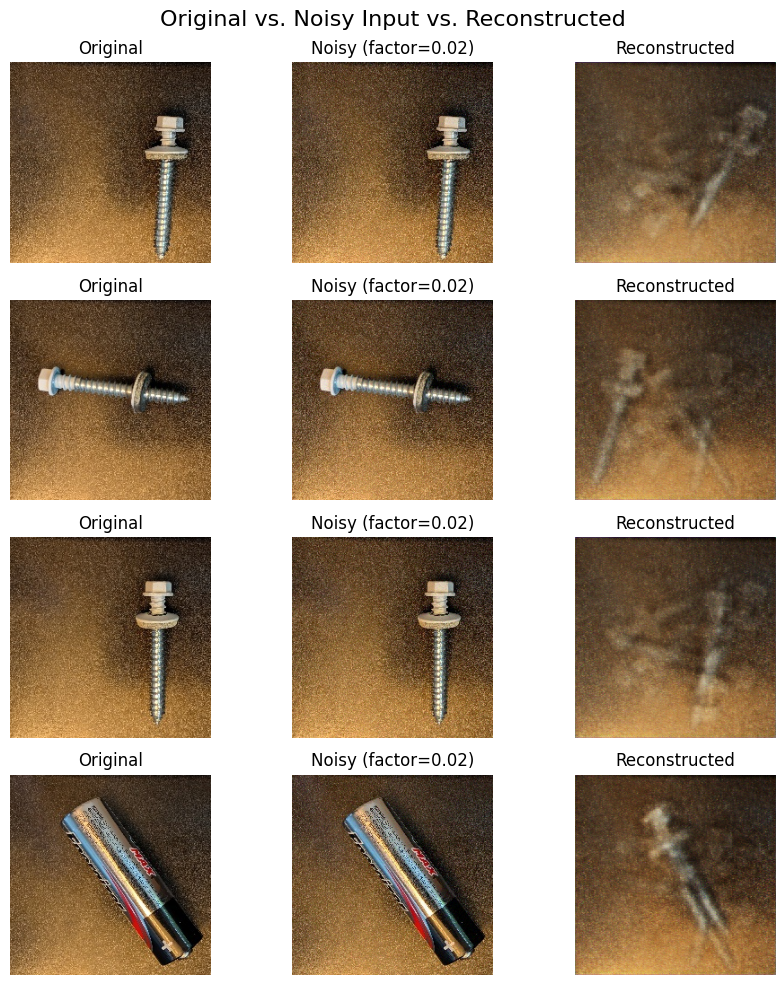

pasta analysis
epoch 0 loss 0.08298823982477188
epoch 1 loss 0.0823073536157608
epoch 2 loss 0.08039326220750809
epoch 3 loss 0.07586488872766495
epoch 4 loss 0.06868505477905273
epoch 5 loss 0.06656159460544586
epoch 6 loss 0.06125956401228905
epoch 7 loss 0.05600032955408096
epoch 8 loss 0.05336132273077965
epoch 9 loss 0.05067284777760506
epoch 10 loss 0.04788065701723099
epoch 11 loss 0.04611137509346008
epoch 12 loss 0.0437263660132885
epoch 13 loss 0.041057027876377106
epoch 14 loss 0.03920450061559677
epoch 15 loss 0.03739316016435623
epoch 16 loss 0.03546581417322159
epoch 17 loss 0.034077730029821396
epoch 18 loss 0.03274741396307945
epoch 19 loss 0.03137480840086937
epoch 20 loss 0.03057974949479103
epoch 21 loss 0.02996259555220604
epoch 22 loss 0.029390808194875717
epoch 23 loss 0.029186341911554337
epoch 24 loss 0.028877533972263336
epoch 25 loss 0.02862337790429592
epoch 26 loss 0.028533978387713432
epoch 27 loss 0.028312018141150475
epoch 28 loss 0.02823037840425968
epoc

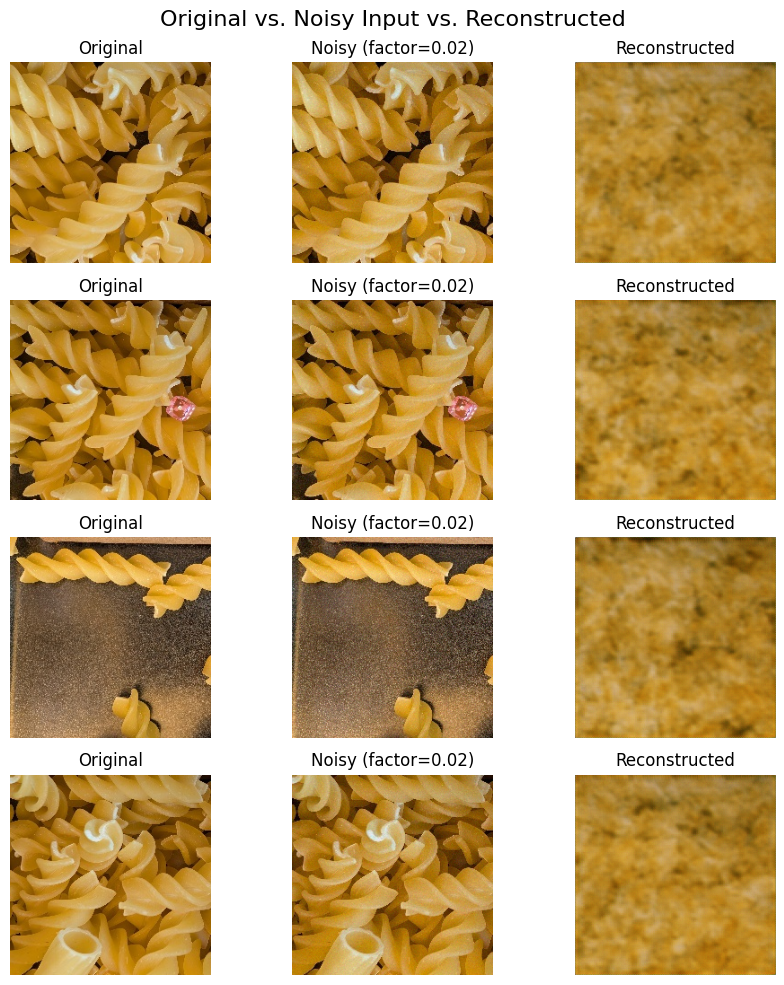

In [36]:
# TODO use class above as well as helper functions to generate
# predictions on the datasets and evaluate the results.

def do_analysis(class_name):
  training_images, testing_images, testing_labels = load_dataset(class_name=class_name)

  img_height = training_images.shape[1]
  img_width = training_images.shape[2]

  basic_model = Basic_AE(img_height, img_width)

  train_model(basic_model, training_images, num_epochs=200)

  predictions = predict(basic_model, testing_images)
  basic_evaluation(predictions, testing_labels)

  print(f"\nVisualizing sample reconstructions for {class_name}...")
  visualize_reconstructions(basic_model, testing_images, num_images=4)

print("screws analysis")
do_analysis('screws')
print("pasta analysis")
do_analysis('pasta')
